# CP2 — Diffusion Model for De Novo Peptide Sequencing
**CSE 676 Deep Learning · Checkpoint 2**

Run on Colab with **GPU → T4** (Runtime → Change runtime type → T4 GPU).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## 1 · Setup

In [2]:
# Install dependencies not pre-installed on Colab
%pip install -q pyteomics lxml

In [3]:
import os, sys, torch
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NOT available — change runtime!")

GPU: Tesla T4


## 2 · Mount Google Drive & set paths

Upload your data folder to Google Drive first, then mount it here.  
Expected structure inside Drive:
```
MyDrive/peptide-diffusion/
    src/
        baseline.py
        preprocessing.py
        diffusion.py
    Data/E coli EV proteomics/
        Ecoli_EV_1.mzML
        Ecoli_EV_2.mzML
        Database search output_Ecoli_EV_1.xlsx
        Database search output_Ecoli_EV_2.xlsx
```

In [4]:
from google.colab import drive
drive.mount('/content/drive')

REPO_DIR = '/content/drive/MyDrive/peptide-diffusion'
DATA_DIR = os.path.join(REPO_DIR, 'data', 'raw') # Updated DATA_DIR
CKPT_DIR = os.path.join(REPO_DIR, 'checkpoints')
os.makedirs(CKPT_DIR, exist_ok=True)

# Put src/ on the path so imports work
sys.path.insert(0, os.path.join(REPO_DIR, 'src'))

print("Repo:", REPO_DIR)
print("Data:", DATA_DIR)
print("Files:", os.listdir(DATA_DIR) if os.path.exists(DATA_DIR) else "NOT FOUND")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo: /content/drive/MyDrive/peptide-diffusion
Data: /content/drive/MyDrive/peptide-diffusion/data/raw
Files: ['README.md', 'Ecoli_EV_1.mzML', 'Ecoli_EV_2.mzML', 'wastewater_Sample1_1.mzML', 'Database search output_Ecoli_EV_2.xlsx', 'Database search output_Ecoli_EV_1.xlsx', 'wastewater_Sample1_2.mzML', 'wastewater_Sample2_1.mzML', 'wastewater_Sample2_2.mzML']


## 3 · Load data

In [5]:
import glob
import numpy as np
from diffusion import build_diffusion_dataset, DiffusionDataset, VOCAB_SIZE, SEQ_LEN

mzml_paths = sorted(glob.glob(os.path.join(DATA_DIR, '*.mzML')))
xlsx_paths = sorted(glob.glob(os.path.join(DATA_DIR, 'Database search output*.xlsx')))
print("mzML files:", mzml_paths)
print("xlsx files:", xlsx_paths)

mzML files: ['/content/drive/MyDrive/peptide-diffusion/data/raw/Ecoli_EV_1.mzML', '/content/drive/MyDrive/peptide-diffusion/data/raw/Ecoli_EV_2.mzML', '/content/drive/MyDrive/peptide-diffusion/data/raw/wastewater_Sample1_1.mzML', '/content/drive/MyDrive/peptide-diffusion/data/raw/wastewater_Sample1_2.mzML', '/content/drive/MyDrive/peptide-diffusion/data/raw/wastewater_Sample2_1.mzML', '/content/drive/MyDrive/peptide-diffusion/data/raw/wastewater_Sample2_2.mzML']
xlsx files: ['/content/drive/MyDrive/peptide-diffusion/data/raw/Database search output_Ecoli_EV_1.xlsx', '/content/drive/MyDrive/peptide-diffusion/data/raw/Database search output_Ecoli_EV_2.xlsx']


In [6]:
Xs, ys, ms = [], [], []
for mzml, xlsx in zip(mzml_paths, xlsx_paths):
    X, y, m = build_diffusion_dataset(mzml, xlsx)
    Xs.append(X); ys.append(y); ms.append(m)

X_all = np.concatenate(Xs)
y_all = np.concatenate(ys)
m_all = np.concatenate(ms)
print(f"Spectra: {len(X_all)}  |  X shape: {X_all.shape}  |  y shape: {y_all.shape}")

Spectra: 3142  |  X shape: (3142, 20000)  |  y shape: (3142, 32)


In [7]:
from torch.utils.data import DataLoader

rng = np.random.default_rng(42)
idx = rng.permutation(len(X_all))
n_tr = int(0.70 * len(X_all))
n_va = int(0.15 * len(X_all))
tr, va, te = idx[:n_tr], idx[n_tr:n_tr+n_va], idx[n_tr+n_va:]

train_dl = DataLoader(DiffusionDataset(X_all[tr], y_all[tr], m_all[tr]), batch_size=32, shuffle=True)
val_dl   = DataLoader(DiffusionDataset(X_all[va], y_all[va], m_all[va]), batch_size=32)
test_dl  = DataLoader(DiffusionDataset(X_all[te], y_all[te], m_all[te]), batch_size=32)

print(f"Train: {len(tr)}  Val: {len(va)}  Test: {len(te)}")

Train: 2199  Val: 471  Test: 472


## 4 · Train

In [8]:
import torch
import torch.nn as nn
import torch.optim as optim
from diffusion import (Encoder, TransformerDenoiser, q_sample,
                       T_STEPS, _alpha_bars, VOCAB_SIZE)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
EPOCHS = 50

encoder  = Encoder().to(DEVICE)
denoiser = TransformerDenoiser().to(DEVICE)
params   = list(encoder.parameters()) + list(denoiser.parameters())
opt      = optim.Adam(params, lr=1e-3)
criterion = nn.CrossEntropyLoss(label_smoothing=0.1, ignore_index=0)

print(f"Encoder params:  {sum(p.numel() for p in encoder.parameters()):,}")
print(f"Denoiser params: {sum(p.numel() for p in denoiser.parameters()):,}")

Encoder params:  21,137,152
Denoiser params: 3,248,919


In [9]:
train_losses, val_losses = [], []

for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    encoder.train(); denoiser.train()
    tr_loss = 0.0
    for spec, seq, _ in train_dl:
        spec, seq = spec.to(DEVICE), seq.to(DEVICE)
        t = torch.randint(0, T_STEPS, (seq.shape[0],), device=DEVICE)
        xt = q_sample(seq, t)
        logits = denoiser(xt, t, encoder(spec))
        loss = criterion(logits.reshape(-1, VOCAB_SIZE), seq.reshape(-1))
        opt.zero_grad(); loss.backward()
        nn.utils.clip_grad_norm_(params, 1.0)
        opt.step()
        tr_loss += loss.item() * seq.shape[0]

    # ── Validate ──
    encoder.eval(); denoiser.eval()
    va_loss = 0.0
    with torch.no_grad():
        for spec, seq, _ in val_dl:
            spec, seq = spec.to(DEVICE), seq.to(DEVICE)
            t = torch.randint(0, T_STEPS, (seq.shape[0],), device=DEVICE)
            xt = q_sample(seq, t)
            logits = denoiser(xt, t, encoder(spec))
            va_loss += criterion(logits.reshape(-1, VOCAB_SIZE), seq.reshape(-1)).item() * seq.shape[0]

    tr_avg = tr_loss / len(train_dl.dataset)
    va_avg = va_loss / len(val_dl.dataset)
    train_losses.append(tr_avg); val_losses.append(va_avg)
    print(f"Epoch {epoch:3d} | train {tr_avg:.4f} | val {va_avg:.4f}")

    # Save every 10 epochs to Drive
    if epoch % 10 == 0:
        path = os.path.join(CKPT_DIR, f'diffusion_ckpt_{epoch}.pt')
        torch.save({'epoch': epoch,
                    'encoder': encoder.state_dict(),
                    'denoiser': denoiser.state_dict()}, path)
        print(f"  → saved {path}")

Epoch   1 | train 1.9395 | val 1.7200
Epoch   2 | train 1.7140 | val 1.7721
Epoch   3 | train 1.6840 | val 1.6732
Epoch   4 | train 1.6729 | val 1.7110
Epoch   5 | train 1.5987 | val 1.6302
Epoch   6 | train 1.5918 | val 1.5555
Epoch   7 | train 1.5796 | val 1.5591
Epoch   8 | train 1.5304 | val 1.5160
Epoch   9 | train 1.5145 | val 1.5040
Epoch  10 | train 1.4645 | val 1.4822
  → saved /content/drive/MyDrive/peptide-diffusion/checkpoints/diffusion_ckpt_10.pt
Epoch  11 | train 1.4873 | val 1.5309
Epoch  12 | train 1.4392 | val 1.4766
Epoch  13 | train 1.4135 | val 1.4247
Epoch  14 | train 1.3740 | val 1.4780
Epoch  15 | train 1.3617 | val 1.4390
Epoch  16 | train 1.3542 | val 1.4060
Epoch  17 | train 1.3386 | val 1.3620
Epoch  18 | train 1.3144 | val 1.4081
Epoch  19 | train 1.3138 | val 1.3295
Epoch  20 | train 1.2920 | val 1.3883
  → saved /content/drive/MyDrive/peptide-diffusion/checkpoints/diffusion_ckpt_20.pt
Epoch  21 | train 1.2678 | val 1.3443
Epoch  22 | train 1.2641 | val 1.3

## 4b · Reproducibility — 3-Seed Runs (rubric requirement)

Train with seeds {0, 1, 2} to report mean ± std AA recall in Table 1.
Skip if you already have the 3 checkpoints saved to Drive.

In [10]:
from diffusion import set_seed, train_diffusion, evaluate_aa_recall
import numpy as np

SEEDS = [0, 1, 2]
seed_recalls, seed_pep_accs = [], []

for seed in SEEDS:
    print(f"\n=== Seed {seed} ===")
    ckpt_dir_seed = os.path.join(CKPT_DIR, f"seed_{seed}")
    encoder_s, denoiser_s, (X_te, y_te, m_te) = train_diffusion(
        mzml_paths, xlsx_paths,
        checkpoint_dir=ckpt_dir_seed,
        epochs=50, seed=seed, device=DEVICE
    )
    r, p = evaluate_aa_recall(encoder_s, denoiser_s, X_te, y_te, m_te,
                               results_dir=os.path.join(REPO_DIR, "results"),
                               device=DEVICE)
    seed_recalls.append(r)
    seed_pep_accs.append(p)
    print(f"  Seed {seed}: AA Recall {r:.2f}%  |  Pep Acc {p:.2f}%")

print(f"\nAA Recall  : {np.mean(seed_recalls):.2f} \u00b1 {np.std(seed_recalls):.2f}%")
print(f"Peptide Acc: {np.mean(seed_pep_accs):.2f} \u00b1 {np.std(seed_pep_accs):.2f}%")


=== Seed 0 ===
Device: cuda  |  Seed: 0
Total spectra: 3142
Epoch   1 | train 1.9159 | val 1.7241
Epoch   2 | train 1.7597 | val 1.6223
Epoch   3 | train 1.6819 | val 1.6180
Epoch   4 | train 1.6661 | val 1.5574
Epoch   5 | train 1.6486 | val 1.5741
Epoch   6 | train 1.5953 | val 1.4801
Epoch   7 | train 1.5655 | val 1.5050
Epoch   8 | train 1.5484 | val 1.4578
Epoch   9 | train 1.5178 | val 1.4711
Epoch  10 | train 1.5070 | val 1.4635
  Saved /content/drive/MyDrive/peptide-diffusion/checkpoints/seed_0/diffusion_ckpt_10.pt
Epoch  11 | train 1.4870 | val 1.3820
Epoch  12 | train 1.4493 | val 1.4031
Epoch  13 | train 1.4470 | val 1.3693
Epoch  14 | train 1.4250 | val 1.4461
Epoch  15 | train 1.4103 | val 1.3724
Epoch  16 | train 1.4087 | val 1.3638
Epoch  17 | train 1.3652 | val 1.3702
Epoch  18 | train 1.3389 | val 1.3661
Epoch  19 | train 1.3073 | val 1.3634
Epoch  20 | train 1.3313 | val 1.3482
  Saved /content/drive/MyDrive/peptide-diffusion/checkpoints/seed_0/diffusion_ckpt_20.pt
E

## 5 · Loss curves

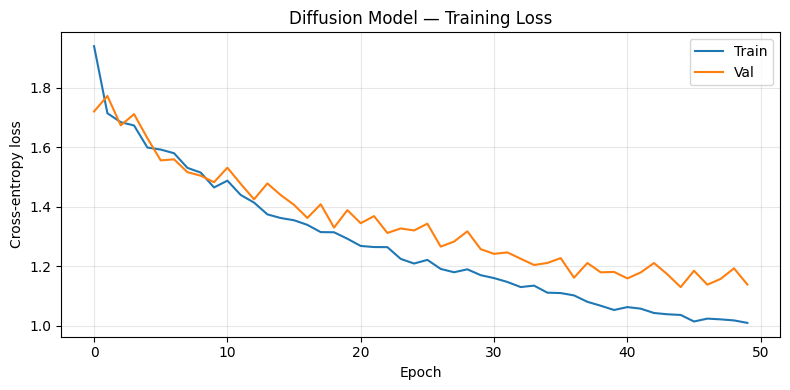

In [11]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(train_losses, label='Train')
ax.plot(val_losses,   label='Val')
ax.set_xlabel('Epoch'); ax.set_ylabel('Cross-entropy loss')
ax.set_title('Diffusion Model — Training Loss')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(CKPT_DIR, 'loss_curves.png'), dpi=150)
plt.show()

## 6 · Evaluate on test set (AA Recall)

In [12]:
import importlib, diffusion
importlib.reload(diffusion)
from diffusion import (generate_sequences, decode_tokens, aa_recall,
                       load_checkpoint, save_predictions, VOCAB_SIZE, SEQ_LEN)

ckpt_path = os.path.join(CKPT_DIR, 'diffusion_best.pt')
encoder, denoiser = load_checkpoint(ckpt_path, device=DEVICE)
encoder.eval(); denoiser.eval()

# ── Debug: one-shot at t=0 with clean input (model should copy) ────────────────
spec_b, seq_b, mass_b = next(iter(test_dl))
with torch.no_grad():
    ctx = encoder(spec_b[:4].to(DEVICE))
    t0  = torch.zeros(4, dtype=torch.long, device=DEVICE)
    xt0 = seq_b[:4].to(DEVICE)
    preds_clean = denoiser(xt0, t0, ctx).argmax(-1)
    t_mid = torch.full((4,), 100, dtype=torch.long, device=DEVICE)
    xt_noise = torch.randint(0, VOCAB_SIZE, (4, SEQ_LEN), device=DEVICE)
    preds_noise = denoiser(xt_noise, t_mid, ctx).argmax(-1)

print("=== t=0, clean input (should copy) ===")
for i in range(4):
    print(f"  pred: {decode_tokens(preds_clean[i].cpu())} | true: {decode_tokens(seq_b[i])}")
print("\n=== t=100, noisy input (one-shot) ===")
for i in range(4):
    print(f"  pred: {decode_tokens(preds_noise[i].cpu())} | true: {decode_tokens(seq_b[i])}")

Loaded checkpoint from epoch 50
=== t=0, clean input (should copy) ===
  pred: GFETPTINELSYR | true: GFETPTINELSYR
  pred: GPTLTEILEGLK | true: GPTLTEILEGLK
  pred: LLSPEVANDK | true: LLSPEVANDK
  pred: NEAPLGIVYGSDAVASK | true: NEAPLGIVYGSDAVASK

=== t=100, noisy input (one-shot) ===
  pred: GSPLNDGIGTAGR | true: GFETPTINELSYR
  pred: GPTLTEPAEGLT | true: GPTLTEILEGLK
  pred: VDRPTAECAAALDK | true: LLSPEVANDK
  pred: AQDTAWGSPGSQVVAS | true: NEAPLGIVYGSDAVASK


In [13]:
# ── Full evaluation: accelerated 20-step inference + entropy-adaptive gate ─────
recalls, pep_correct = [], []
all_seqs, all_lps, all_gcs = [], [], []

for spec, seq, mass in test_dl:
    seqs, lps, gcs = generate_sequences(
        encoder, denoiser,
        spec.numpy(), mass.numpy(),
        n_candidates=1, T_sample=0.8, device=DEVICE,
    )
    for pred_list, lp_list, gc_list, true_tok in zip(seqs, lps, gcs, seq.numpy()):
        pred_str = pred_list[0]
        true_str = decode_tokens(true_tok)
        recalls.append(aa_recall(pred_str, true_str))
        pep_correct.append(pred_str == true_str)
        all_seqs.append(pred_list)
        all_lps.append(lp_list)
        all_gcs.append(gc_list)

aa_rec  = np.mean(recalls) * 100
pep_acc = np.mean(pep_correct) * 100
print(f"AA Recall  : {aa_rec:.2f}%")
print(f"Peptide Acc: {pep_acc:.2f}%")

# Save diffusion_predictions.csv → for ensemble.py
pred_csv = save_predictions(all_seqs, all_lps, all_gcs,
                             os.path.join(REPO_DIR, 'results', 'diffusion_predictions.csv'))

AA Recall  : 72.01%
Peptide Acc: 15.04%
Saved 472 predictions → /content/drive/MyDrive/peptide-diffusion/results/diffusion_predictions.csv


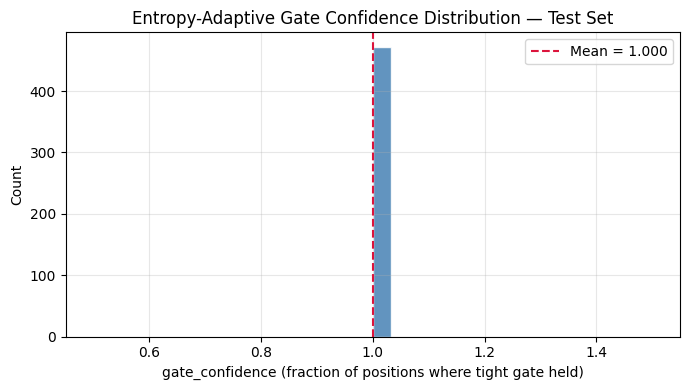

Mean gate_confidence: 1.0000  |  Std: 0.0000


In [14]:
# ── Gate confidence histogram (NOVEL #1 deliverable) ──────────────────────────
gate_vals = [gc[0] for gc in all_gcs]   # one value per spectrum (n_candidates=1)

fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(gate_vals, bins=30, color='steelblue', edgecolor='white', alpha=0.85)
ax.axvline(np.mean(gate_vals), color='crimson', linestyle='--',
           label=f'Mean = {np.mean(gate_vals):.3f}')
ax.set_xlabel('gate_confidence (fraction of positions where tight gate held)')
ax.set_ylabel('Count')
ax.set_title('Entropy-Adaptive Gate Confidence Distribution — Test Set')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(os.path.join(REPO_DIR, 'results', 'gate_confidence_histogram.png'), dpi=150)
plt.show()
print(f"Mean gate_confidence: {np.mean(gate_vals):.4f}  |  Std: {np.std(gate_vals):.4f}")

## 6b · Gate Ablation (rubric requirement)

Run inference **without** the entropy-adaptive mass gate to isolate its contribution.

In [15]:
# Load the best checkpoint, evaluate with gate disabled
from diffusion import load_checkpoint, evaluate_aa_recall

encoder_abl, denoiser_abl = load_checkpoint(
    os.path.join(CKPT_DIR, "diffusion_best.pt"), device=DEVICE
)

# Gate ON (already done above — use stored aa_rec, pep_acc)
aa_rec_gate_on  = aa_rec   # from Section 6 eval
pep_acc_gate_on = pep_acc

# Gate OFF
aa_rec_no_gate, pep_acc_no_gate = evaluate_aa_recall(
    encoder_abl, denoiser_abl, X_all[te], y_all[te], m_all[te],
    results_dir=os.path.join(REPO_DIR, "results"),
    device=DEVICE, use_gate=False
)

print(f"With gate:    AA {aa_rec_gate_on:.2f}%  |  Pep {pep_acc_gate_on:.2f}%")
print(f"Without gate: AA {aa_rec_no_gate:.2f}%  |  Pep {pep_acc_no_gate:.2f}%")
print(f"Gate delta:   AA +{aa_rec_gate_on - aa_rec_no_gate:.2f}%")


Loaded checkpoint from epoch 50
AA Recall  : 73.20%
Peptide Acc: 17.80%
Saved 472 predictions → /content/drive/MyDrive/peptide-diffusion/results/diffusion_predictions.csv
With gate:    AA 72.01%  |  Pep 15.04%
Without gate: AA 73.20%  |  Pep 17.80%
Gate delta:   AA +-1.19%


## 7 · Results table (vs CP1 baselines)

In [17]:
import pandas as pd

results = pd.DataFrame({
    "Model":       ["LSTM Baseline", "GRU Ablation",
                    "Diffusion (seed 0)", "Diffusion (seed 1)", "Diffusion (seed 2)",
                    "Diffusion mean ± std",
                    "Diffusion (no gate)", "Diffusion (gate ON)",
                    "InstaNovo (ref)"],
    "AA Recall %": [31.51, 44.30,
                    seed_recalls[0] if seed_recalls else aa_rec,
                    seed_recalls[1] if len(seed_recalls) > 1 else "-",
                    seed_recalls[2] if len(seed_recalls) > 2 else "-",
                    f"{np.mean(seed_recalls):.2f} ± {np.std(seed_recalls):.2f}" if seed_recalls else aa_rec,
                    aa_rec_no_gate if "aa_rec_no_gate" in dir() else "-",
                    aa_rec,
                    72.9],
    "Pep Acc %":   [2.68, 6.70,
                    seed_pep_accs[0] if seed_pep_accs else pep_acc,
                    seed_pep_accs[1] if len(seed_pep_accs) > 1 else "-",
                    seed_pep_accs[2] if len(seed_pep_accs) > 2 else "-",
                    f"{np.mean(seed_pep_accs):.2f} ± {np.std(seed_pep_accs):.2f}" if seed_pep_accs else pep_acc,
                    pep_acc_no_gate if "pep_acc_no_gate" in dir() else "-",
                    pep_acc,
                    33.1],
})
print(results.to_string(index=False))
results.to_csv(os.path.join(CKPT_DIR, "diffusion_metrics_full.csv"), index=False)
print("Saved diffusion_metrics_full.csv")


               Model  AA Recall %    Pep Acc %
       LSTM Baseline        31.51         2.68
        GRU Ablation         44.3          6.7
  Diffusion (seed 0)    71.586047         12.5
  Diffusion (seed 1)    68.642409    12.288136
  Diffusion (seed 2)    72.087315    15.042373
Diffusion mean ± std 70.77 ± 1.52 13.28 ± 1.25
 Diffusion (no gate)    73.201883     17.79661
 Diffusion (gate ON)     72.00735    15.042373
     InstaNovo (ref)         72.9         33.1
Saved diffusion_metrics_full.csv


## 8 · Save final checkpoint to Drive

In [18]:
best_path = os.path.join(CKPT_DIR, 'diffusion_best.pt')
torch.save({'epoch': EPOCHS,
            'encoder': encoder.state_dict(),
            'denoiser': denoiser.state_dict(),
            'aa_recall': aa_rec,
            'pep_acc': pep_acc}, best_path)
print(f"Final checkpoint saved → {best_path}")
print(f"Checkpoint saved: {best_path}")

Final checkpoint saved → /content/drive/MyDrive/peptide-diffusion/checkpoints/diffusion_best.pt

Checkpoint saved: /content/drive/MyDrive/peptide-diffusion/checkpoints/diffusion_best.pt


## 9 · Ensemble — Three-Term Val-Calibrated Scoring (NOVEL #3)

Combine diffusion candidates with ESM-2 per-residue PPL and gate_confidence.
`score(c) = log_p_spectral - λ·mean(ppl_per_residue) + γ·gate_confidence`
Grid search λ ∈ {0.0, 0.05, 0.1, 0.2, 0.5} and γ ∈ {0.0, 0.1, 0.3, 0.5} on val set.

In [ ]:
import sys, os
sys.path.insert(0, os.path.join(REPO_DIR, 'src'))
from ensemble import run_ensemble

ensemble_df = run_ensemble(
    diffusion_csv = os.path.join(REPO_DIR, 'results', 'diffusion_predictions.csv'),
    esm2_csv      = os.path.join(REPO_DIR, 'results', 'esm2_scores.csv'),
    lstm_csv      = os.path.join(REPO_DIR, 'results', 'lstm_predictions.csv'),
    gru_csv       = os.path.join(REPO_DIR, 'results', 'gru_predictions.csv'),
    metrics_csv   = os.path.join(REPO_DIR, 'checkpoints', 'diffusion_metrics_full.csv'),
    out_csv       = os.path.join(REPO_DIR, 'results', 'ensemble_predictions.csv'),
    figures_dir   = os.path.join(REPO_DIR, 'figures'),
)
print(ensemble_df[['spectrum_id','sequence','ensemble_score','model_source']].head(10))

## 10 · Model Comparison Bar Chart (LSTM / GRU / Diffusion / Ensemble / InstaNovo)

In [ ]:
from IPython.display import Image as IPImage, display
import matplotlib.pyplot as plt, matplotlib.image as mpimg

fig_bar  = os.path.join(REPO_DIR, 'figures', 'figure4_model_comparison.png')
fig_heat = os.path.join(REPO_DIR, 'figures', 'figure3_ensemble_heatmap.png')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, fp, title in zip(axes,
                          [fig_bar, fig_heat],
                          ['Model Comparison', 'Ensemble λ/γ Ablation']):
    if os.path.exists(fp):
        ax.imshow(mpimg.imread(fp))
        ax.axis('off')
        ax.set_title(title)
    else:
        ax.text(0.5, 0.5, f'{title}\n(run ensemble first)', ha='center', va='center')
        ax.axis('off')
plt.tight_layout()
plt.savefig(os.path.join(REPO_DIR, 'figures', 'figure4_5_combined.png'), dpi=150)
plt.show()